# Chapter 6: Advanced Logistic Regression and Extensions

## 📋 Summary

Despite its name, logistic regression is a **classification** algorithm, not a regression one. It is one of the most widely used models in industry due to its interpretability, speed, and strong probabilistic foundation. This chapter covers binary logistic regression, multiclass strategies (OvR and OvO), multilabel classification, regularization in logistic regression, and a complete set of classification evaluation metrics.

---

## 🧠 Theoretical Explanation

### Logistic Regression
Logistic regression models the **probability** that a sample belongs to class 1:

`P(y=1|X) = σ(Xβ) = 1 / (1 + e^(-Xβ))`

where σ is the **sigmoid function** that maps any real value to (0, 1). The decision boundary is at `P=0.5`.

**Training** minimizes the **cross-entropy loss** (log loss):

`Loss = -Σ[yi·log(ŷi) + (1-yi)·log(1-ŷi)]`

### Regularization in Logistic Regression
- `penalty='l2'` (default): Ridge-like regularization. `C = 1/α` (smaller C = stronger regularization)
- `penalty='l1'`: Lasso-like, produces sparse solutions (requires solver='liblinear' or 'saga')
- `penalty='elasticnet'`: Combined (requires solver='saga')

### Multiclass Strategies
- **One-vs-Rest (OvR)**: Train C binary classifiers, each class vs all others. Predict class with highest confidence.
- **One-vs-One (OvO)**: Train C(C-1)/2 classifiers, each pair of classes. Predict by majority vote.
- **Multinomial**: Directly extends logistic regression using softmax function. More principled but requires compatible solver.

### Evaluation Metrics for Classification
- **Accuracy**: `(TP+TN) / total` — misleading for imbalanced classes
- **Precision**: `TP / (TP+FP)` — how many predicted positives are truly positive
- **Recall (Sensitivity)**: `TP / (TP+FN)` — how many actual positives were caught
- **F1 Score**: `2·(Precision·Recall)/(Precision+Recall)` — harmonic mean of precision and recall
- **ROC-AUC**: Area under the ROC curve — measures discrimination ability


## 6.1 Binary Logistic Regression

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=cancer.target_names))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

ROC-AUC: 0.9974


## 6.2 Regularization Comparison

In [2]:
from sklearn.model_selection import cross_val_score
import pandas as pd

cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

configs = [
    ('No regularization', LogisticRegression(C=1e6, max_iter=1000)),
    ('L2 C=1.0', LogisticRegression(penalty='l2', C=1.0, max_iter=1000)),
    ('L2 C=0.1', LogisticRegression(penalty='l2', C=0.1, max_iter=1000)),
    ('L1 C=1.0', LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=1000)),
]

results = []
for name, lr in configs:
    pipe = Pipeline([('scaler', StandardScaler()), ('lr', lr)])
    score = cross_val_score(pipe, X, y, cv=5, scoring='accuracy').mean()
    results.append({'Config': name, 'CV Accuracy': round(score, 4)})

pd.DataFrame(results)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

,Config,CV Accuracy
0,No regularization,0.9561
1,L2 C=1.0,0.9807
2,L2 C=0.1,0.9772
3,L1 C=1.0,0.9737


## 6.3 Multiclass Classification

In [3]:
from sklearn.datasets import load_iris
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.model_selection import cross_val_score

iris = load_iris()
X, y = iris.data, iris.target

# OvR
ovr = Pipeline([('s', StandardScaler()), ('m', OneVsRestClassifier(LogisticRegression(max_iter=200)))])
# OvO
ovo = Pipeline([('s', StandardScaler()), ('m', OneVsOneClassifier(LogisticRegression(max_iter=200)))])
# Multinomial (direct)
multi = Pipeline([('s', StandardScaler()), ('m', LogisticRegression(max_iter=200))])

for name, pipe in [('OvR', ovr), ('OvO', ovo), ('Multinomial', multi)]:
    score = cross_val_score(pipe, X, y, cv=5).mean()
    print(f'{name:15s}: {score:.4f}')

OvR            : 0.9267
OvO            : 0.9667
Multinomial    : 0.9600


## 6.4 ROC Curve and Precision-Recall Curve

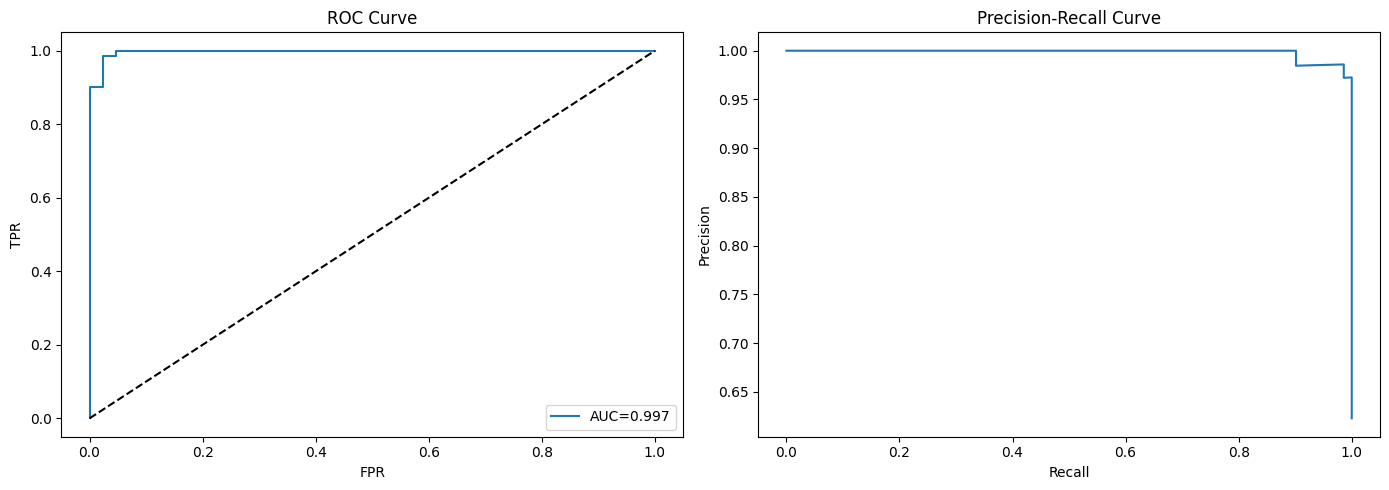

In [4]:
from sklearn.metrics import roc_curve, precision_recall_curve, RocCurveDisplay
import matplotlib.pyplot as plt

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=42)

pipe = Pipeline([('s', StandardScaler()), ('lr', LogisticRegression(max_iter=1000))])
pipe.fit(X_train, y_train)
y_proba = pipe.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[0].plot(fpr, tpr, label=f'AUC={auc:.3f}')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(recall, precision)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout(); plt.show()

## 🔑 Key Takeaways

- Logistic regression outputs **probabilities** via the sigmoid function — ideal when you need calibrated probabilities.
- Use `C` to control regularization: smaller `C` = stronger regularization.
- `L1` regularization gives sparse models (feature selection); `L2` is the safe default.
- For multiclass: `multinomial` with `solver='lbfgs'` is usually best; `OvR` is simple and effective.
- Accuracy alone is misleading — always look at precision, recall, F1, and ROC-AUC.
- Use `predict_proba()` when you need probability scores, not just hard class assignments.
